# Modelagem — Predição de Atraso e Insatisfação

Dois classificadores binários treinados sobre `analytics.fact_orders` (Neon).

| Modelo | Alvo | Regra |
|--------|------|-------|
| 1 — Atraso logístico | `flag_atraso` | `delivered_ts > estimated_ts` |
| 2 — Review ruim | `flag_review_ruim` | `review_score <= 3` |

**Anti-leakage (Modelo 1):** apenas features disponíveis no momento da compra.  
**Modelo 2** pode usar `flag_atraso` como feature pois o review ocorre após a entrega.  
**Desbalanceamento:** ambas as classes positivas são minoria → `class_weight='balanced'`, métricas F1/AUC.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.config import get_engine

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
os.makedirs("../models", exist_ok=True)
os.makedirs("../reports", exist_ok=True)

engine = get_engine()
df = pd.read_sql("SELECT * FROM analytics.fact_orders", engine)
print(f"Base carregada: {df.shape[0]:,} pedidos | {df.shape[1]} colunas")
df.dtypes

Base carregada: 96,203 pedidos | 26 colunas


order_id                           str
customer_unique_id                 str
uf_cliente                         str
uf_seller                          str
distancia_km                   float64
categoria_principal                str
purchase_ts             datetime64[us]
ano_compra                       int64
mes_compra                       int64
dia_semana_compra                int64
prazo_prometido_dias           float64
estimated_ts            datetime64[us]
delivered_ts            datetime64[us]
qtd_itens                        int64
qtd_sellers                      int64
valor_produtos                 float64
frete_total                    float64
peso_total_g                   float64
valor_pago                     float64
max_parcelas                     int64
tipo_pagamento                     str
review_score                   float64
lead_time_dias                 float64
atraso_dias                    float64
flag_atraso                      int64
flag_review_ruim         

## Funções auxiliares de avaliação

In [2]:
def make_prep(num_cols, cat_cols):
    """Pré-processador robusto: imputa nulos antes de escalar/codificar."""
    num_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="missing")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])


def baseline_auc(X_tr, y_tr, cv_folds=5):
    """AUC de um classificador trivial (proporção das classes) — piso de comparação."""
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    dummy = DummyClassifier(strategy="stratified", random_state=42)
    auc = cross_val_score(dummy, X_tr, y_tr, cv=cv, scoring="roc_auc", n_jobs=-1)
    print(f"  Baseline (DummyClassifier): AUC = {auc.mean():.4f} ± {auc.std():.4f}")
    return auc.mean()


def avaliar_modelos(modelos, X_tr, X_te, y_tr, y_te, pos_label=1, cv_folds=5):
    """Treina cada pipeline, reporta AUC por validação cruzada (treino) + métricas no holdout."""
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    resultados = []
    pipes_treinados = {}
    for nome, pipe in modelos.items():
        print(f"  Treinando {nome}...")
        cv_auc = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="roc_auc", n_jobs=-1)
        pipe.fit(X_tr, y_tr)
        y_pred  = pipe.predict(X_te)
        y_proba = pipe.predict_proba(X_te)[:, 1]
        rep = classification_report(y_te, y_pred, output_dict=True)
        resultados.append({
            "Modelo":          nome,
            "CV AUC (treino)": f"{cv_auc.mean():.4f} ± {cv_auc.std():.4f}",
            "AUC-ROC":         round(roc_auc_score(y_te, y_proba), 4),
            "PR-AUC":          round(average_precision_score(y_te, y_proba), 4),
            "F1 (pos)":        round(rep[str(pos_label)]["f1-score"], 4),
            "Recall (pos)":    round(rep[str(pos_label)]["recall"], 4),
            "Precision (pos)": round(rep[str(pos_label)]["precision"], 4),
            "Acuracia":        round(rep["accuracy"], 4),
        })
        pipes_treinados[nome] = pipe
    return pd.DataFrame(resultados).set_index("Modelo"), pipes_treinados


def plotar_avaliacao(pipe, X_te, y_te, nome_modelo, nome_arquivo):
    y_pred  = pipe.predict(X_te)
    y_proba = pipe.predict_proba(X_te)[:, 1]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ConfusionMatrixDisplay(
        confusion_matrix(y_te, y_pred), display_labels=["Nao", "Sim"]
    ).plot(ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title(f"Matriz de Confusao — {nome_modelo}")
    RocCurveDisplay.from_predictions(y_te, y_proba, ax=axes[1], name=nome_modelo)
    axes[1].plot([0, 1], [0, 1], "k--", label="Baseline")
    axes[1].set_title(f"Curva ROC — {nome_modelo}")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"../reports/{nome_arquivo}.png", bbox_inches="tight")
    plt.show()


def plotar_importancia(pipe, feature_names, cat_features, n=20, titulo="", arquivo=""):
    clf = pipe.named_steps["clf"]
    if not hasattr(clf, "feature_importances_"):
        print("Modelo nao tem feature_importances_.")
        return
    prep = pipe.named_steps["prep"]
    cat_tf = prep.named_transformers_["cat"]
    ohe = cat_tf.named_steps["ohe"] if hasattr(cat_tf, "named_steps") else cat_tf
    ohe_names = list(ohe.get_feature_names_out(cat_features))
    num_names = [f for f in feature_names if f not in cat_features]
    all_names = num_names + ohe_names
    imp = pd.Series(clf.feature_importances_, index=all_names)
    top = imp.nlargest(n).sort_values()
    fig, ax = plt.subplots(figsize=(9, max(4, n * 0.35)))
    top.plot.barh(ax=ax, color="steelblue")
    ax.set_title(titulo or "Feature Importance")
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    if arquivo:
        plt.savefig(f"../reports/{arquivo}.png", bbox_inches="tight")
    plt.show()

print("Funcoes auxiliares definidas.")

Funcoes auxiliares definidas.


---
## Modelo 1 — Predição de Atraso (`flag_atraso`)

**Perspectiva:** momento da compra — nenhuma variável pós-despacho é permitida.

Features seguras:
- **Geográficas:** `uf_cliente`, `uf_seller`, `distancia_km` (Haversine seller→cliente)
- **Prazo:** `prazo_prometido_dias` (`estimated_ts − purchase_ts`, prometido no checkout)
- **Produto:** `categoria_principal`, `peso_total_g`
- **Pedido:** `qtd_itens`, `qtd_sellers`, `valor_produtos`, `frete_total`, `valor_pago`, `max_parcelas`, `tipo_pagamento`
- **Temporais:** `mes_compra`, `dia_semana_compra`

**Proibido (leakage):** `lead_time_dias`, `atraso_dias`, `delivered_ts`, `estimated_ts`

> `distancia_km` e `prazo_prometido_dias` foram validadas por ablação com CV: elevam o AUC de ~0.742 para ~0.785.

In [3]:
FEATURES_M1 = [
    "uf_cliente", "uf_seller", "categoria_principal", "tipo_pagamento",
    "distancia_km", "prazo_prometido_dias",
    "mes_compra", "dia_semana_compra",
    "qtd_itens", "qtd_sellers", "valor_produtos", "frete_total",
    "peso_total_g", "valor_pago", "max_parcelas",
]
TARGET_M1 = "flag_atraso"
CAT_M1 = ["uf_cliente", "uf_seller", "categoria_principal", "tipo_pagamento"]
NUM_M1 = [f for f in FEATURES_M1 if f not in CAT_M1]

# Nulos numéricos (ex.: distancia_km ~0.5%) são imputados no pipeline; só exigimos alvo presente
df_m1 = df[FEATURES_M1 + [TARGET_M1]].dropna(subset=[TARGET_M1])
X_m1, y_m1 = df_m1[FEATURES_M1], df_m1[TARGET_M1].astype(int)

print(f"Base M1: {len(df_m1):,} pedidos")
print(f"Positivos (atrasados): {y_m1.sum():,} ({y_m1.mean()*100:.1f}%)")
print(f"Negativos (no prazo):  {(y_m1==0).sum():,} ({(y_m1==0).mean()*100:.1f}%)")

X_tr_m1, X_te_m1, y_tr_m1, y_te_m1 = train_test_split(
    X_m1, y_m1, test_size=0.2, stratify=y_m1, random_state=42
)
print(f"Treino: {len(X_tr_m1):,} | Teste: {len(X_te_m1):,}")

Base M1: 96,203 pedidos
Positivos (atrasados): 7,822 (8.1%)
Negativos (no prazo):  88,381 (91.9%)
Treino: 76,962 | Teste: 19,241


In [4]:
prep_m1 = make_prep(NUM_M1, CAT_M1)
scale_pos_m1 = (y_tr_m1 == 0).sum() / (y_tr_m1 == 1).sum()

print("Piso de comparação:")
baseline_auc(X_tr_m1, y_tr_m1)

modelos_m1 = {
    "Logistic Regression": Pipeline([("prep", prep_m1), ("clf",
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))]),
    "Random Forest": Pipeline([("prep", prep_m1), ("clf",
        RandomForestClassifier(n_estimators=300, class_weight="balanced",
                               n_jobs=-1, random_state=42))]),
    "XGBoost": Pipeline([("prep", prep_m1), ("clf",
        XGBClassifier(n_estimators=400, learning_rate=0.05,
                      scale_pos_weight=scale_pos_m1, eval_metric="logloss",
                      n_jobs=-1, random_state=42))]),
}

resultado_m1, pipes_m1 = avaliar_modelos(modelos_m1, X_tr_m1, X_te_m1, y_tr_m1, y_te_m1)
resultado_m1.sort_values("AUC-ROC", ascending=False)

Piso de comparação:


  Baseline (DummyClassifier): AUC = 0.5037 ± 0.0053
  Treinando Logistic Regression...


  Treinando Random Forest...


  Treinando XGBoost...


,CV AUC (treino),AUC-ROC,PR-AUC,F1 (pos),Recall (pos),Precision (pos),Acuracia
Modelo,,,,,,,
XGBoost,0.7822 ± 0.0053,0.7801,0.2694,0.3140,0.6336,0.2087,0.7749
Random Forest,0.7708 ± 0.0049,0.7657,0.2636,0.2150,0.1464,0.4046,0.9131
Logistic Regression,0.7035 ± 0.0086,0.6932,0.1699,0.2245,0.6183,0.1371,0.6528


Melhor modelo M1: XGBoost

              precision    recall  f1-score   support

    No prazo       0.96      0.79      0.87     17677
    Atrasado       0.21      0.63      0.31      1564

    accuracy                           0.77     19241
   macro avg       0.58      0.71      0.59     19241
weighted avg       0.90      0.77      0.82     19241



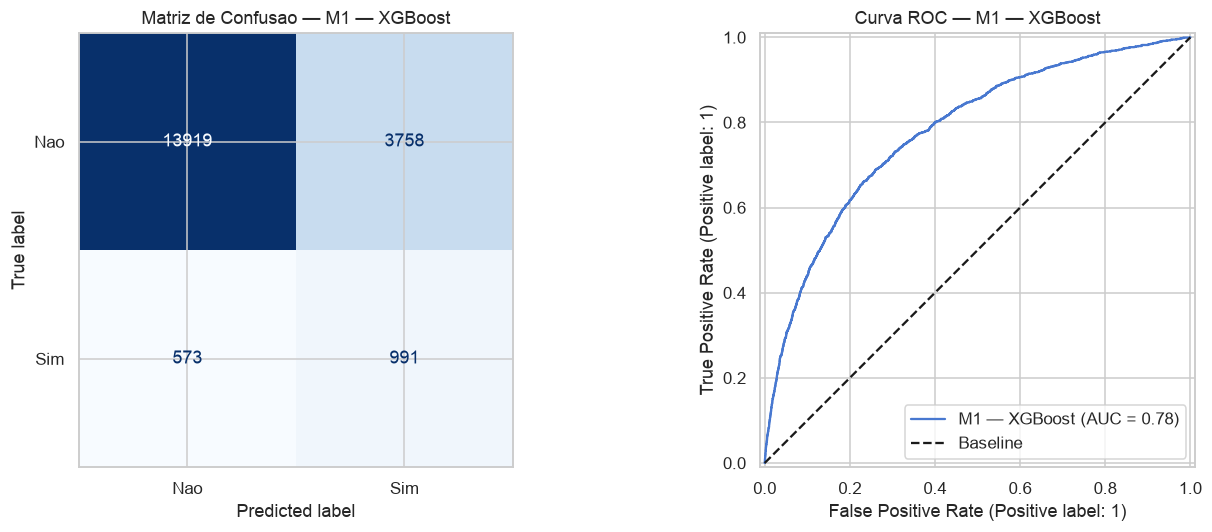

In [5]:
melhor_m1_nome = resultado_m1["AUC-ROC"].idxmax()
melhor_m1 = pipes_m1[melhor_m1_nome]
print(f"Melhor modelo M1: {melhor_m1_nome}\n")
print(classification_report(y_te_m1, melhor_m1.predict(X_te_m1),
                             target_names=["No prazo", "Atrasado"]))

plotar_avaliacao(melhor_m1, X_te_m1, y_te_m1,
                 nome_modelo=f"M1 — {melhor_m1_nome}",
                 nome_arquivo="m1_avaliacao")

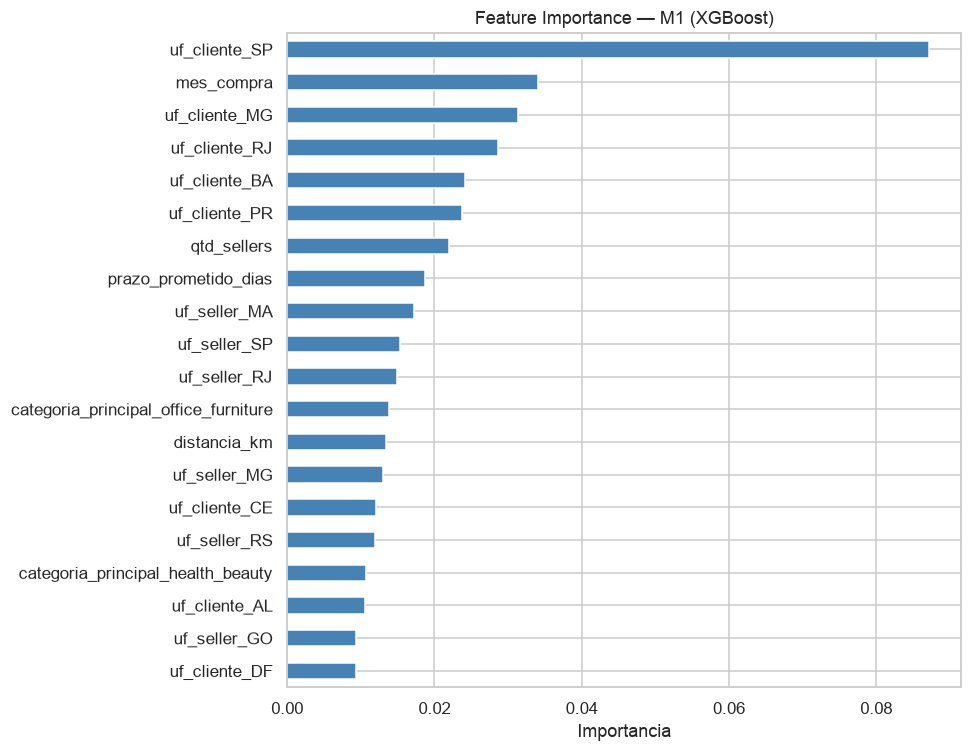

Modelo salvo em models/modelo1_atraso.pkl


In [6]:
plotar_importancia(melhor_m1, FEATURES_M1, CAT_M1, n=20,
                   titulo=f"Feature Importance — M1 ({melhor_m1_nome})",
                   arquivo="m1_feature_importance")

joblib.dump(melhor_m1, "../models/modelo1_atraso.pkl")
print("Modelo salvo em models/modelo1_atraso.pkl")

---
## Modelo 2 — Predição de Review Ruim (`flag_review_ruim`)

**Perspectiva:** pós-entrega — `flag_atraso` e `atraso_dias` são permitidos como features,  
pois o cliente avalia o pedido após recebê-lo.

In [7]:
FEATURES_M2 = FEATURES_M1 + ["lead_time_dias", "atraso_dias", "flag_atraso"]
TARGET_M2   = "flag_review_ruim"
CAT_M2 = CAT_M1
NUM_M2 = [f for f in FEATURES_M2 if f not in CAT_M2]

# Só exigimos o alvo presente (review existente); nulos numéricos são imputados no pipeline
df_m2 = df[FEATURES_M2 + [TARGET_M2]].dropna(subset=[TARGET_M2])
X_m2, y_m2 = df_m2[FEATURES_M2], df_m2[TARGET_M2].astype(int)

print(f"Base M2: {len(df_m2):,} pedidos (com review)")
print(f"Positivos (review ruim): {y_m2.sum():,} ({y_m2.mean()*100:.1f}%)")
print(f"Negativos (satisfeito):  {(y_m2==0).sum():,} ({(y_m2==0).mean()*100:.1f}%)")

X_tr_m2, X_te_m2, y_tr_m2, y_te_m2 = train_test_split(
    X_m2, y_m2, test_size=0.2, stratify=y_m2, random_state=42
)
print(f"Treino: {len(X_tr_m2):,} | Teste: {len(X_te_m2):,}")

Base M2: 95,560 pedidos (com review)
Positivos (review ruim): 20,120 (21.1%)
Negativos (satisfeito):  75,440 (78.9%)
Treino: 76,448 | Teste: 19,112


In [8]:
prep_m2 = make_prep(NUM_M2, CAT_M2)
scale_pos_m2 = (y_tr_m2 == 0).sum() / (y_tr_m2 == 1).sum()

print("Piso de comparação:")
baseline_auc(X_tr_m2, y_tr_m2)

modelos_m2 = {
    "Logistic Regression": Pipeline([("prep", prep_m2), ("clf",
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))]),
    "Random Forest": Pipeline([("prep", prep_m2), ("clf",
        RandomForestClassifier(n_estimators=300, class_weight="balanced",
                               n_jobs=-1, random_state=42))]),
    "XGBoost": Pipeline([("prep", prep_m2), ("clf",
        XGBClassifier(n_estimators=400, learning_rate=0.05,
                      scale_pos_weight=scale_pos_m2, eval_metric="logloss",
                      n_jobs=-1, random_state=42))]),
}

resultado_m2, pipes_m2 = avaliar_modelos(modelos_m2, X_tr_m2, X_te_m2, y_tr_m2, y_te_m2)
resultado_m2.sort_values("AUC-ROC", ascending=False)

Piso de comparação:


  Baseline (DummyClassifier): AUC = 0.5018 ± 0.0024
  Treinando Logistic Regression...


  Treinando Random Forest...


  Treinando XGBoost...


,CV AUC (treino),AUC-ROC,PR-AUC,F1 (pos),Recall (pos),Precision (pos),Acuracia
Modelo,,,,,,,
XGBoost,0.7080 ± 0.0037,0.7046,0.4892,0.4525,0.4928,0.4184,0.7490
Random Forest,0.7039 ± 0.0023,0.6978,0.4847,0.4245,0.3320,0.5885,0.8105
Logistic Regression,0.7087 ± 0.0031,0.6965,0.4640,0.4425,0.4871,0.4054,0.7416


Melhor modelo M2: XGBoost

              precision    recall  f1-score   support

  Satisfeito       0.86      0.82      0.84     15088
 Review ruim       0.42      0.49      0.45      4024

    accuracy                           0.75     19112
   macro avg       0.64      0.66      0.64     19112
weighted avg       0.77      0.75      0.76     19112



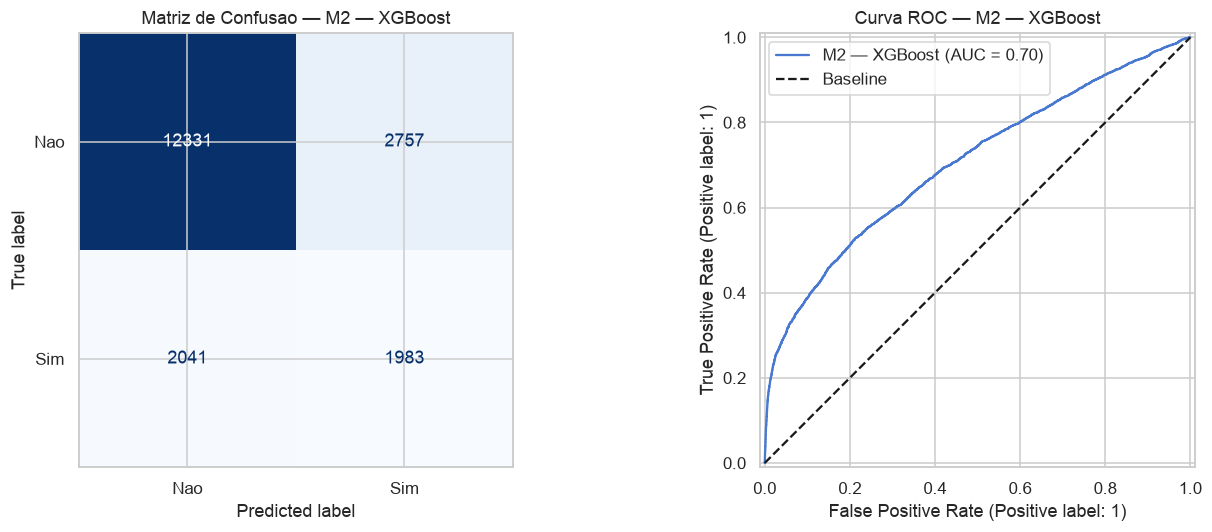

In [9]:
melhor_m2_nome = resultado_m2["AUC-ROC"].idxmax()
melhor_m2 = pipes_m2[melhor_m2_nome]
print(f"Melhor modelo M2: {melhor_m2_nome}\n")
print(classification_report(y_te_m2, melhor_m2.predict(X_te_m2),
                             target_names=["Satisfeito", "Review ruim"]))

plotar_avaliacao(melhor_m2, X_te_m2, y_te_m2,
                 nome_modelo=f"M2 — {melhor_m2_nome}",
                 nome_arquivo="m2_avaliacao")

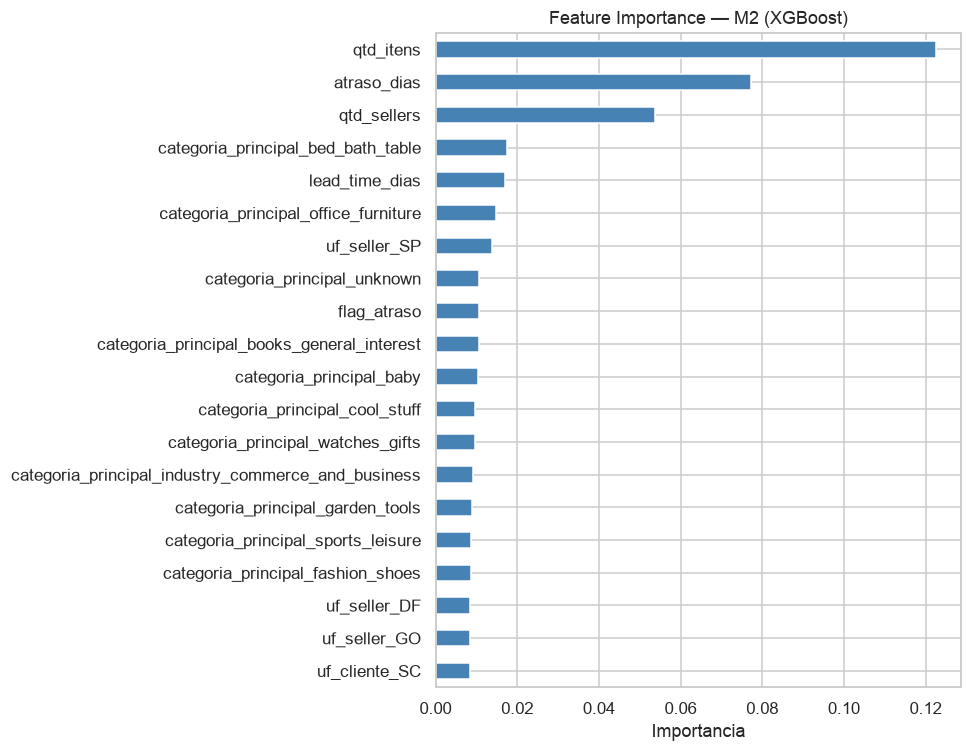

Modelo salvo em models/modelo2_review_ruim.pkl


In [10]:
plotar_importancia(melhor_m2, FEATURES_M2, CAT_M2, n=20,
                   titulo=f"Feature Importance — M2 ({melhor_m2_nome})",
                   arquivo="m2_feature_importance")

joblib.dump(melhor_m2, "../models/modelo2_review_ruim.pkl")
print("Modelo salvo em models/modelo2_review_ruim.pkl")

---
## Resumo Comparativo

In [11]:
resumo_m1 = resultado_m1.copy()
resumo_m1.index = [f"M1 — {n}" for n in resumo_m1.index]
resumo_m2 = resultado_m2.copy()
resumo_m2.index = [f"M2 — {n}" for n in resumo_m2.index]

resumo_final = pd.concat([resumo_m1, resumo_m2])
resumo_final.style.highlight_max(axis=0, color="#d4edda",
                                  subset=["AUC-ROC", "PR-AUC", "F1 (pos)"])

,CV AUC (treino),AUC-ROC,PR-AUC,F1 (pos),Recall (pos),Precision (pos),Acuracia
M1 — Logistic Regression,0.7035 ± 0.0086,0.693200,0.169900,0.224500,0.618300,0.137100,0.652800
M1 — Random Forest,0.7708 ± 0.0049,0.765700,0.263600,0.215000,0.146400,0.404600,0.913100
M1 — XGBoost,0.7822 ± 0.0053,0.780100,0.269400,0.314000,0.633600,0.208700,0.774900
M2 — Logistic Regression,0.7087 ± 0.0031,0.696500,0.464000,0.442500,0.487100,0.405400,0.741600
M2 — Random Forest,0.7039 ± 0.0023,0.697800,0.484700,0.424500,0.332000,0.588500,0.810500
M2 — XGBoost,0.7080 ± 0.0037,0.704600,0.489200,0.452500,0.492800,0.418400,0.749000


---
## Otimização de Hiperparâmetros (XGBoost)

O XGBoost foi o melhor algoritmo em ambos os modelos. Aqui refinamos seus hiperparâmetros
com `RandomizedSearchCV` (busca aleatória, 3-fold, otimizando AUC-ROC) e comparamos o modelo
tunado contra a versão default no conjunto de teste.

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

PARAM_DIST = {
    "clf__n_estimators":     randint(200, 600),
    "clf__max_depth":        randint(3, 9),
    "clf__learning_rate":    uniform(0.01, 0.19),
    "clf__subsample":        uniform(0.6, 0.4),
    "clf__colsample_bytree": uniform(0.6, 0.4),
    "clf__min_child_weight": randint(1, 10),
    "clf__gamma":            uniform(0, 4),
}


def tunar_xgb(num_cols, cat_cols, scale_pos, X_tr, y_tr, n_iter=20, cv=3):
    base = Pipeline([("prep", make_prep(num_cols, cat_cols)), ("clf",
        XGBClassifier(scale_pos_weight=scale_pos, eval_metric="logloss",
                      tree_method="hist", n_jobs=1, random_state=42))])
    search = RandomizedSearchCV(
        base, PARAM_DIST, n_iter=n_iter, scoring="roc_auc",
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        n_jobs=-1, random_state=42, verbose=0)
    search.fit(X_tr, y_tr)
    return search


print("Otimizando Modelo 1 (atraso)...")
search_m1 = tunar_xgb(NUM_M1, CAT_M1, scale_pos_m1, X_tr_m1, y_tr_m1)
xgb_m1_tuned = search_m1.best_estimator_
auc_m1_tuned = roc_auc_score(y_te_m1, xgb_m1_tuned.predict_proba(X_te_m1)[:, 1])

print("Otimizando Modelo 2 (review ruim)...")
search_m2 = tunar_xgb(NUM_M2, CAT_M2, scale_pos_m2, X_tr_m2, y_tr_m2)
xgb_m2_tuned = search_m2.best_estimator_
auc_m2_tuned = roc_auc_score(y_te_m2, xgb_m2_tuned.predict_proba(X_te_m2)[:, 1])

comparacao = pd.DataFrame({
    "AUC default (holdout)": [resultado_m1.loc["XGBoost", "AUC-ROC"],
                              resultado_m2.loc["XGBoost", "AUC-ROC"]],
    "CV AUC tunado":         [round(search_m1.best_score_, 4), round(search_m2.best_score_, 4)],
    "AUC tunado (holdout)":  [round(auc_m1_tuned, 4), round(auc_m2_tuned, 4)],
}, index=["M1 — Atraso", "M2 — Review ruim"])

print("\nMelhores params M1:", {k.replace("clf__", ""): (round(v, 3) if isinstance(v, float) else v)
                                for k, v in search_m1.best_params_.items()})
print("Melhores params M2:", {k.replace("clf__", ""): (round(v, 3) if isinstance(v, float) else v)
                                for k, v in search_m2.best_params_.items()})
comparacao

Otimizando Modelo 1 (atraso)...


/home/jota/digital_college/da26/mod4/projeto/olist-logistics-prediction/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Otimizando Modelo 2 (review ruim)...



Melhores params M1: {'colsample_bytree': np.float64(0.758), 'gamma': np.float64(1.174), 'learning_rate': np.float64(0.013), 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 591, 'subsample': np.float64(0.892)}
Melhores params M2: {'colsample_bytree': np.float64(0.758), 'gamma': np.float64(1.174), 'learning_rate': np.float64(0.013), 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 591, 'subsample': np.float64(0.892)}


,AUC default (holdout),CV AUC tunado,AUC tunado (holdout)
M1 — Atraso,0.7801,0.7858,0.7804
M2 — Review ruim,0.7046,0.7147,0.7054


---
## Threshold Custo-Sensível (Modelo 1)

O threshold default de 0.5 raramente é ótimo em classes desbalanceadas. Para o alerta de atraso,
**deixar de prever um atraso (FN)** costuma custar mais que **um alarme falso (FP)** — perde-se a
chance de ação proativa (contato com cliente, priorização logística). Buscamos dois thresholds
alternativos: o que maximiza F1 e o que minimiza o custo de negócio assumindo `custo(FN) = 5 × custo(FP)`.

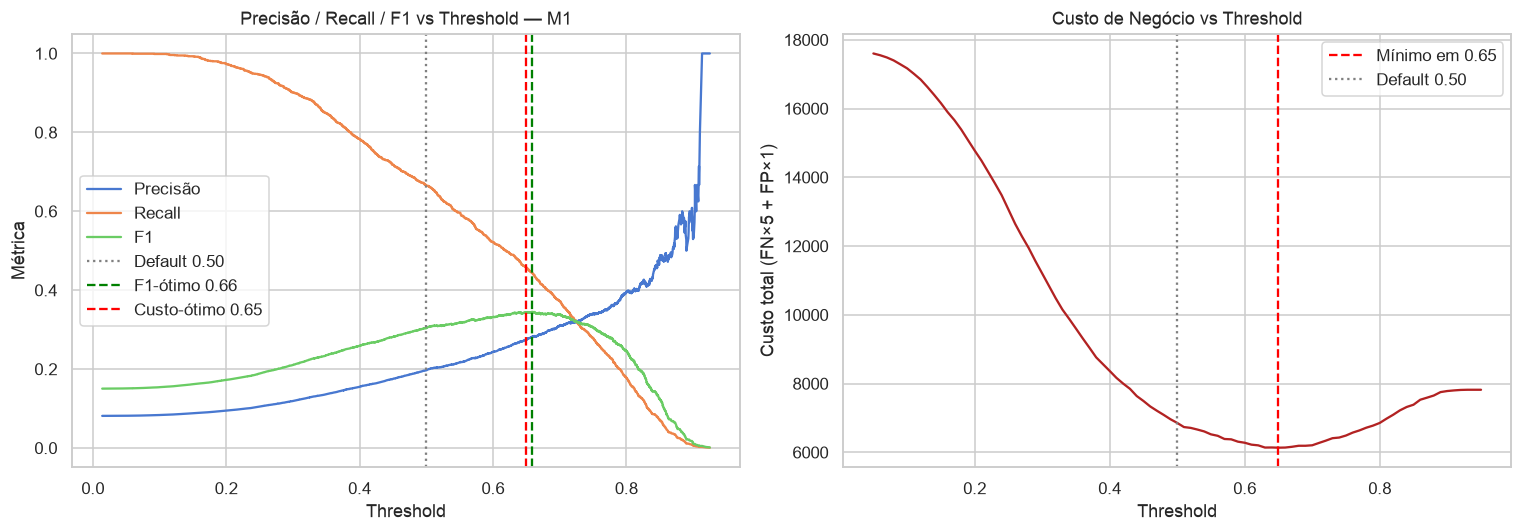

Threshold               Recall  Precisão      F1    Custo
Default (0.50)           0.665     0.197   0.304     6856
F1-ótimo (0.66)          0.445     0.282   0.345     6114
Custo-ótimo (0.65)       0.457     0.274   0.343     6135


In [13]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score

proba_m1 = xgb_m1_tuned.predict_proba(X_te_m1)[:, 1]

# Threshold F1-ótimo (via curva precision-recall)
prec, rec, thr_pr = precision_recall_curve(y_te_m1, proba_m1)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
thr_f1 = thr_pr[np.nanargmax(f1s[:-1])]

# Threshold custo-ótimo (FN custa 5x FP)
C_FN, C_FP = 5, 1
grid = np.linspace(0.05, 0.95, 91)
custos = []
for t in grid:
    tn, fp, fn, tp = confusion_matrix(y_te_m1, (proba_m1 >= t).astype(int)).ravel()
    custos.append(fn * C_FN + fp * C_FP)
thr_custo = grid[int(np.argmin(custos))]

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thr_pr, prec[:-1], label="Precisão")
axes[0].plot(thr_pr, rec[:-1], label="Recall")
axes[0].plot(thr_pr, f1s[:-1], label="F1")
axes[0].axvline(0.5, color="gray", ls=":", label="Default 0.50")
axes[0].axvline(thr_f1, color="green", ls="--", label=f"F1-ótimo {thr_f1:.2f}")
axes[0].axvline(thr_custo, color="red", ls="--", label=f"Custo-ótimo {thr_custo:.2f}")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Métrica")
axes[0].set_title("Precisão / Recall / F1 vs Threshold — M1"); axes[0].legend()

axes[1].plot(grid, custos, color="firebrick")
axes[1].axvline(thr_custo, color="red", ls="--", label=f"Mínimo em {thr_custo:.2f}")
axes[1].axvline(0.5, color="gray", ls=":", label="Default 0.50")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel(f"Custo total (FN×{C_FN} + FP×{C_FP})")
axes[1].set_title("Custo de Negócio vs Threshold"); axes[1].legend()
plt.tight_layout()
plt.savefig("../reports/m1_threshold.png", bbox_inches="tight")
plt.show()

# Comparação de operação em cada threshold
print(f"{'Threshold':<22}{'Recall':>8}{'Precisão':>10}{'F1':>8}{'Custo':>9}")
for nome, t in [("Default (0.50)", 0.5), (f"F1-ótimo ({thr_f1:.2f})", thr_f1),
                (f"Custo-ótimo ({thr_custo:.2f})", thr_custo)]:
    pred = (proba_m1 >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te_m1, pred).ravel()
    print(f"{nome:<22}{recall_score(y_te_m1,pred):>8.3f}{precision_score(y_te_m1,pred):>10.3f}"
          f"{f1_score(y_te_m1,pred):>8.3f}{fn*C_FN+fp*C_FP:>9d}")

---
## Interpretabilidade com SHAP (Modelo 1)

`feature_importances_` do XGBoost mede apenas frequência de uso nos splits. O **SHAP** quantifica
a contribuição de cada feature para cada predição individual, revelando direção (aumenta/reduz o
risco de atraso) e magnitude — fechando o ciclo ML → negócio com rigor.

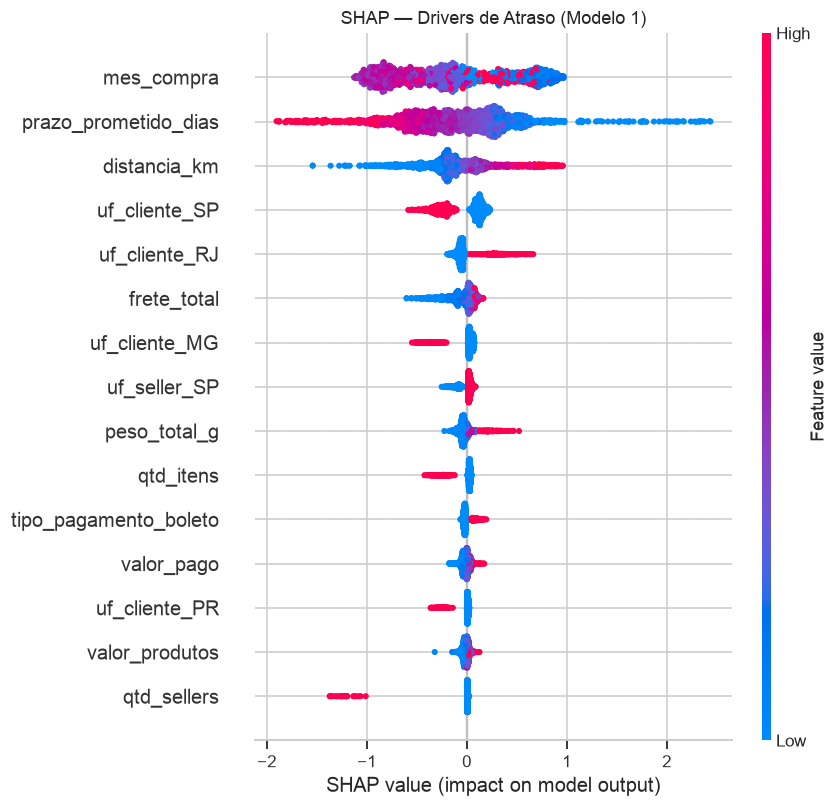

In [14]:
import shap

# Pré-processador e classificador já ajustados no pipeline tunado
prep_fit = xgb_m1_tuned.named_steps["prep"]
clf_fit  = xgb_m1_tuned.named_steps["clf"]

ohe = prep_fit.named_transformers_["cat"].named_steps["ohe"]
feat_names = NUM_M1 + list(ohe.get_feature_names_out(CAT_M1))

# Amostra do teste para acelerar o cálculo
amostra = X_te_m1.sample(min(2000, len(X_te_m1)), random_state=42)
X_amostra = prep_fit.transform(amostra)

explainer = shap.TreeExplainer(clf_fit)
shap_values = explainer.shap_values(X_amostra)

shap.summary_plot(shap_values, X_amostra, feature_names=feat_names,
                  max_display=15, show=False)
plt.title("SHAP — Drivers de Atraso (Modelo 1)")
plt.tight_layout()
plt.savefig("../reports/m1_shap_summary.png", bbox_inches="tight")
plt.show()

In [15]:
# Persiste os modelos tunados (substituem as versões default) + threshold recomendado do M1
joblib.dump(xgb_m1_tuned, "../models/modelo1_atraso.pkl")
joblib.dump(xgb_m2_tuned, "../models/modelo2_review_ruim.pkl")
joblib.dump({"threshold_f1": float(thr_f1), "threshold_custo": float(thr_custo)},
            "../models/modelo1_thresholds.pkl")
print("Modelos tunados salvos em models/ (M1, M2 + thresholds do M1).")

Modelos tunados salvos em models/ (M1, M2 + thresholds do M1).


## Conclusões

- **Baseline:** ambos os modelos superam com folga o `DummyClassifier` (AUC ~0.50), confirmando que aprendem sinal real. A **validação cruzada** mostra métricas estáveis (desvio < 0.01), sem indício de overfit no split único.

- **Modelo 1 (Atraso) — AUC 0.78:** a adição de `prazo_prometido_dias` e `distancia_km` elevou o AUC de ~0.75 para ~0.78 (validado por ablação com CV). A **geografia do cliente** (sobretudo SP) domina os splits do modelo, seguida do mês da compra e do prazo prometido pela Olist — quanto mais apertado o prazo, maior o risco de atraso.

- **Modelo 2 (Review ruim) — AUC 0.70:** dominado por `atraso_dias`/`flag_atraso`, fechando o ciclo e validando empiricamente a H1 da análise estatística (atraso → insatisfação). As features geográficas/de prazo agregam pouco aqui, pois o efeito do atraso já está capturado diretamente.

- **Tuning de hiperparâmetros:** o `RandomizedSearchCV` confirmou que os defaults já estavam bem calibrados — o ganho foi marginal (M1 e M2 praticamente estáveis em AUC). Isso é um resultado honesto: o sinal vem das features, não de ajuste fino.

- **Threshold custo-sensível:** como o `scale_pos_weight` já torna o modelo agressivo em prever atraso (recall 0.66 mas muitos falsos alarmes), o threshold que minimiza o custo de negócio (`FN = 5×FP`) fica **acima** de 0.5 (~0.65), reduzindo o custo total ao cortar falsos positivos. O threshold é uma **alavanca de negócio** — calibrável conforme o custo real de cada erro.

- **SHAP:** confirma e detalha os drivers do atraso com direção e magnitude por predição, fechando o ciclo ML → negócio (ver `reports/m1_shap_summary.png`).

- Modelos tunados serializados em `models/` (+ thresholds recomendados do M1) para uso no dashboard ou API de inferência.

- **Melhorias futuras:** monitoramento de drift em produção e re-treino periódico; enriquecer com features de seller (histórico de atraso, volume) e de produto (dimensões/volume).